In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

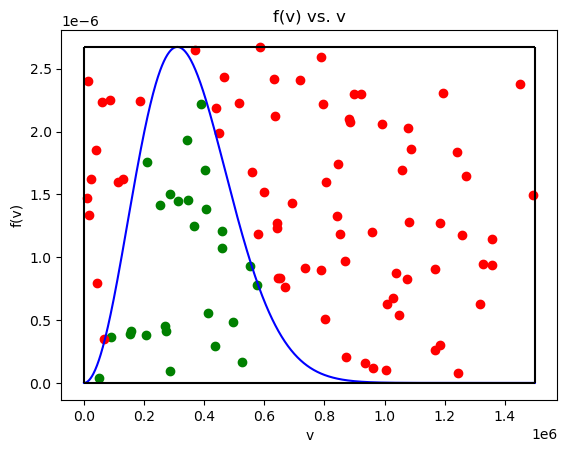

Efficieny = 0.2600
Probability of rejecting is: 0.7400
Mean Speed: 335267
Root-Mean Square Speed: 362039


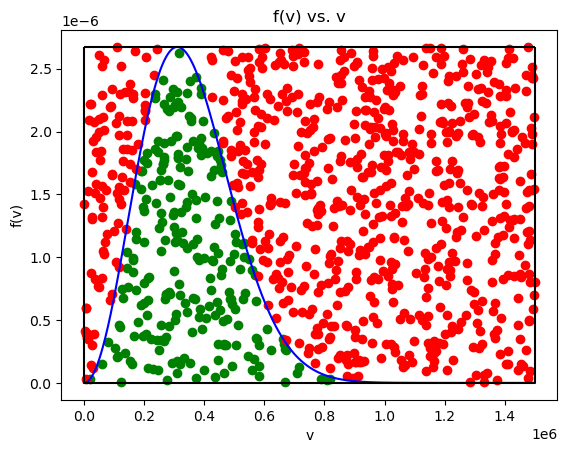

Efficieny = 0.2450
Probability of rejecting is: 0.7550
Mean Speed: 350292
Root-Mean Square Speed: 378415


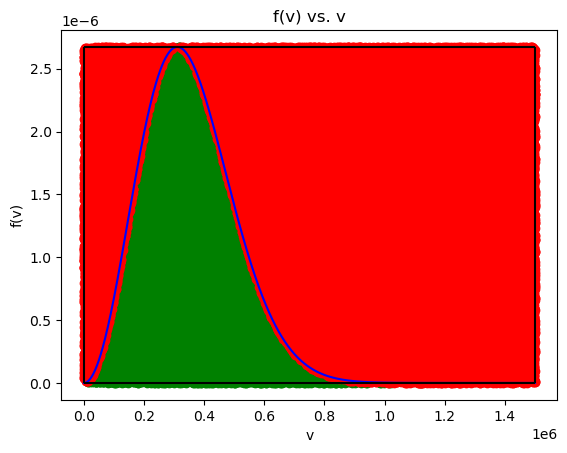

Efficieny = 0.2497
Probability of rejecting is: 0.7503
Mean Speed: 349254
Root-Mean Square Speed: 379349
********************************************
Analytical Efficiency: 0.2495


In [5]:
xmin = 0
xmax = 1.5e6 # arbitrarily found that this is accurate enough to represent the pdf

xs = np.linspace(xmin, xmax, 1000)
pdf = lambda v: 7.530e-17*v**2 * np.exp(-1.036e-11*v**2)
ys = pdf(xs)


N = [100, 1000, 1e5]
# ~18 second runtime

for n in N:
    plt.figure()

    plt.plot(xs, ys, color="blue")

    # Now lets throw darts at this graph
    # Domain is same as pdf function
    # Range is from 0 to max of pdf function
    ymin = 0
    ymax = np.max(ys)
    plt.hlines(ymax, xmin, xmax, color="black")
    plt.hlines(0, xmin, xmax, color="black")
    plt.vlines(xmin, 0, ymax, color="black")
    plt.vlines(xmax, 0, ymax, color="black")
    n1 = rng.random(int(n))
    n2 = rng.random(int(n))
    x = xmin + n1*(xmax-xmin)
    prob = pdf(x)
    
    accept_mask = n2*ymax <= prob
    accepts = n2[accept_mask] * ymax
    mean_speed = np.mean(x[accept_mask])
    root_mean_speed = np.sqrt(np.mean(x[accept_mask]**2))
    plt.scatter(x[accept_mask], accepts, color="green", label="accepts")

    reject_mask = n2*ymax > prob
    rejects = n2[reject_mask] * ymax
    plt.scatter(x[reject_mask], rejects, color="red", label="rejects")

    # plt.legend()
    plt.title("f(v) vs. v")
    plt.ylabel("f(v)")
    plt.xlabel("v")
    plt.show()

    prob_accept = np.sum(accept_mask) / n
    prob_reject = np.sum(reject_mask) / n
    print(f"Efficieny = {prob_accept:.4f}")
    print(f"Probability of rejecting is: {prob_reject:.4f}")
    print(f"Mean Speed: {mean_speed:g}")
    print(f"Root-Mean Square Speed: {root_mean_speed:g}")
    
area = xmax*ymax
analytical_eff = 1.0006/area
print("********************************************")
print(f"Analytical Efficiency: {analytical_eff:.4f}")

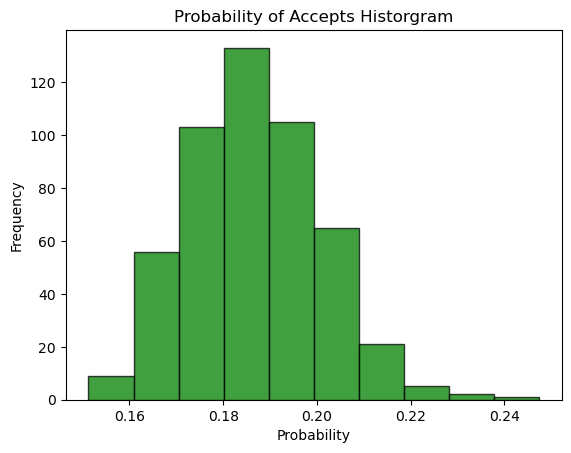

Mean Probability: 0.1867
Standard Deviation of Probability: 0.0143


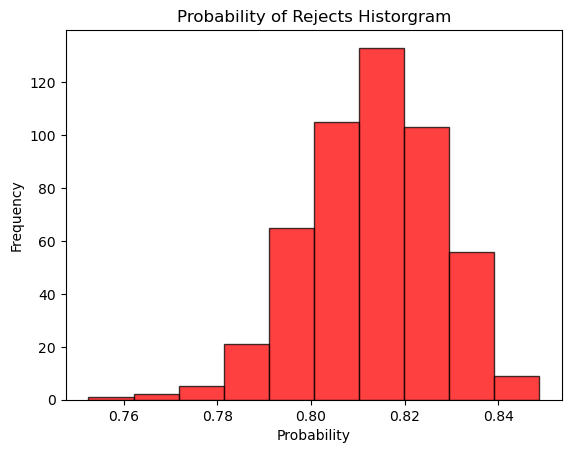

Mean Probability: 0.8133
Standard Deviation of Probability: 0.0143


In [29]:
N = 800 # number of trials
n = 500 # number of tests
def true_prob(N, n):
    test_accepts = np.zeros(n)
    test_rejects = np.zeros(n)
    for k in range(n):
        prob_accept = 0
        prob_reject = 0
        for i in range(N):
            n1 = rng.random()
            n2 = rng.random()
            x = xmin + n1*(xmax - xmin)
            prob = pdf(x)
            if n2*ymax <= prob:
                # we accept
                prob_accept += 1/N
            else:
                # we reject
                prob_reject += 1/N
        test_accepts[k] = prob_accept
        test_rejects[k] = prob_reject
    return test_accepts, test_rejects

accepts, rejects = true_prob(N, n)
plt.hist(accepts, color="green", edgecolor="k", alpha=0.75)
plt.title("Probability of Accepts Historgram")
plt.ylabel("Frequency")
plt.xlabel("Probability")
plt.show()
mean_accepts = np.mean(accepts)
std_accepts = np.std(accepts)
print(f"Mean Probability: {mean_accepts:.4f}")
print(f"Standard Deviation of Probability: {std_accepts:.4f}")

plt.hist(rejects, color="red", edgecolor="k", alpha=0.75)
plt.title("Probability of Rejects Historgram")
plt.ylabel("Frequency")
plt.xlabel("Probability")
plt.show()
mean_rejects = np.mean(rejects)
std_rejects = np.std(rejects)
print(f"Mean Probability: {mean_rejects:.4f}")
print(f"Standard Deviation of Probability: {std_rejects:.4f}")